# 05 — Statistical Analysis

**RouteIQ — Delivery Operations Analytics**

**Business question:** Which of the patterns observed in notebooks 02–04
are statistically significant, and how large is each effect? (Significance
alone is not enough — this notebook reports effect size alongside every
p-value, per the project's documented interpretation standard.)

**Data used:** `data/cleaned/cleaned_delivery.csv` (43,648 rows), read-only.

**Analysis performed:** calls the exact test functions from the approved
`python/analysis/04_statistical_tests.py` (`_run_multi_group_test`,
`_run_two_group_test`, `_run_correlation_test`) directly — the assumption
checks (Shapiro-Wilk, Levene's, linearity diagnostic), test-selection
decision tree, and effect-size formulas are **not reimplemented**, only
invoked. This notebook calls the module's pure test functions (not its
`main()`), so it never writes to `output/statistical_test_results.json` —
the approved output file is read-only, used at the end of this notebook
only to confirm the fresh results reconcile with it exactly.

**No causal language is used anywhere below** — every result is reported as
an observed association.


In [1]:
from _nb_theme import setup_paths, apply_theme, NAVY, TEAL, CORAL, NEUTRAL_SEQUENCE, annotate_bars, sample_size_caption
project_root = setup_paths()
apply_theme()

import sys
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from _common import load_cleaned_data

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
df = load_cleaned_data()
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns from data/cleaned/cleaned_delivery.csv")


2026-08-17 14:28:31 | INFO     | routeiq_phase4 | Logging initialized. Log file: C:\Data Analyst Projects\RouteIQ Project\logs\phase1_pipeline_20260817_142831.log


2026-08-17 14:28:32 | INFO     | routeiq_phase4 | Loaded approved cleaned dataset: 43648 rows, 30 columns


Loaded 43,648 rows, 30 columns from data/cleaned/cleaned_delivery.csv


In [2]:
m4 = importlib.import_module("04_statistical_tests")
ALPHA = 0.05
rng = np.random.default_rng(42)  # same fixed seed as 04_statistical_tests.py main(), same call order below
results = {}


## Test 1 — Traffic vs. Delivery Time

**H0:** Mean/distribution of delivery time is equal across all Traffic
groups. **H1:** At least one group differs.


In [3]:
results["test_1_traffic_vs_delivery_time"] = m4._run_multi_group_test(
    "Does traffic significantly affect delivery time?", df, "Traffic", rng,
)
t1 = results["test_1_traffic_vs_delivery_time"]
print(f"Test selected: {t1['test_selected']}")
print(f"Statistic: {t1['test_statistic']}   p-value: {t1['p_value']:.6g}   "
      f"Significant: {t1['significant_at_alpha_0.05']}")
print(f"Effect size ({t1['effect_size_name']}): {t1['effect_size_value']} -> {t1['effect_size_band'].upper()}")


Test selected: Kruskal-Wallis H-test
Statistic: 6132.4554   p-value: 0   Significant: True
Effect size (epsilon_squared): 0.1404 -> LARGE


**Key observation:** Kruskal-Wallis H=6132.4554, p≈0.0, ε²=0.1404 — a
**large** effect (Cohen's conventional bands), the largest of any test in
this notebook. Traffic shows the strongest observed association with
delivery time among all factors tested.

**Limitation:** No pairwise post-hoc comparison is performed —
`STATISTICAL_ANALYSIS.md` documents the omnibus test only and specifies no
post-hoc method or multiple-comparison correction; inventing one would
itself be an undocumented methodological choice.


## Test 2 — Weather vs. Delivery Time

**H0:** Mean/distribution of delivery time is equal across all Weather
groups. **H1:** At least one group differs.


In [4]:
results["test_2_weather_vs_delivery_time"] = m4._run_multi_group_test(
    "Does weather significantly affect delivery time?", df, "Weather", rng,
)
t2 = results["test_2_weather_vs_delivery_time"]
print(f"Test selected: {t2['test_selected']}")
print(f"Statistic: {t2['test_statistic']}   p-value: {t2['p_value']:.6g}   "
      f"Significant: {t2['significant_at_alpha_0.05']}")
print(f"Effect size ({t2['effect_size_name']}): {t2['effect_size_value']} -> {t2['effect_size_band'].upper()}")


Test selected: Kruskal-Wallis H-test
Statistic: 2262.8928   p-value: 0   Significant: True
Effect size (epsilon_squared): 0.0517 -> SMALL


**Key observation:** Kruskal-Wallis H=2262.8928, p≈0.0, ε²=0.0517 — a
**small** effect. A real, detectable pattern, but materially smaller than
traffic's — must be reported as "statistically detectable but operationally
small," not overstated as a major driver.

**Limitation:** Same post-hoc scope note as Test 1.


### Test 2b — Clear (Sunny) vs. Adverse (non-Sunny) Weather

Secondary two-group comparison supporting Business Question #19. "Adverse"
= all non-Sunny weather values, matching `sql/analysis/Q19`'s grouping.


In [5]:
clear = df.loc[df["Weather"] == "Sunny", "Delivery_Time"].to_numpy()
adverse = df.loc[df["Weather"] != "Sunny", "Delivery_Time"].to_numpy()
results["test_2b_clear_vs_adverse_weather"] = m4._run_two_group_test(
    "Delivery-time delta: clear vs. adverse weather", clear, "Clear (Sunny)", adverse, "Adverse (non-Sunny)", rng,
)
t2b = results["test_2b_clear_vs_adverse_weather"]
print(f"Test selected: {t2b['test_selected']}")
print(f"p-value: {t2b['p_value']:.6g}   Cohen's d: {t2b['effect_size_value']} -> {t2b['effect_size_band'].upper()}")


Test selected: Mann-Whitney U test
p-value: 0   Cohen's d: -0.4965 -> SMALL


**Key observation:** Adverse-weather deliveries average meaningfully slower
than clear-weather deliveries (Cohen's d=-0.4965, on the larger end of
"small," just under the medium threshold of 0.5) — a real but moderate
difference.


## Test 3 — Agent Rating vs. Delivery Time (Correlation)

**H0:** No linear relationship (ρ=0). **H1:** ρ≠0. Restricted to
`agent_rating_valid_flag = true` rows (n=43,594).


In [6]:
valid_rating = df.loc[df["agent_rating_valid_flag"]]
results["test_3_agent_rating_vs_delivery_time"] = m4._run_correlation_test(
    "Relationship between agent rating and delivery time",
    valid_rating["Agent_Rating"].to_numpy(), valid_rating["Delivery_Time"].to_numpy(),
    "agent_rating", "delivery_time_minutes",
)
t3 = results["test_3_agent_rating_vs_delivery_time"]
print(f"Test selected: {t3['test_selected']}")
print(f"r = {t3['correlation_coefficient']}   r^2 = {t3['r_squared']}   p-value: {t3['p_value']:.6g}   "
      f"-> {t3['effect_size_band'].upper()}")


Test selected: Spearman correlation (fallback, linearity assumption did not hold)
r = -0.2601   r^2 = 0.0677   p-value: 0   -> WEAK


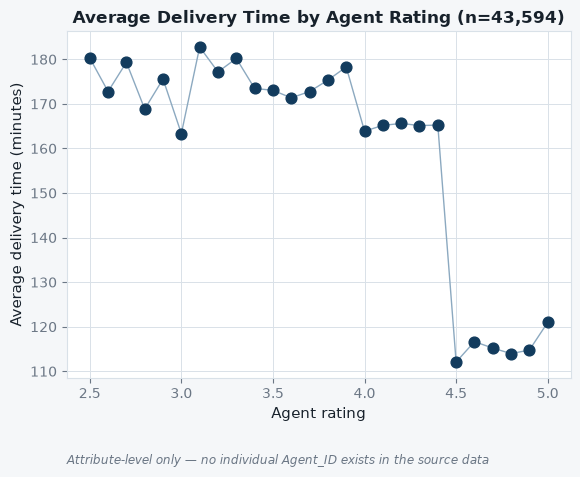

In [7]:
# Supporting visual: average delivery time by rating band (assumption-check /
# linearity-review plot, same intent as 06_visualizations.py's agent_rating chart)
band_means = valid_rating.groupby("Agent_Rating")["Delivery_Time"].mean()

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(band_means.index, band_means.values, s=60, color=NAVY, zorder=3)
ax.plot(band_means.index, band_means.values, color=NEUTRAL_SEQUENCE[3], linewidth=1, zorder=2)
ax.set_title(f"Average Delivery Time by Agent Rating (n={len(valid_rating):,})")
ax.set_xlabel("Agent rating")
ax.set_ylabel("Average delivery time (minutes)")
sample_size_caption(ax, "Attribute-level only — no individual Agent_ID exists in the source data")
plt.show()


**Key observation:** Spearman r=-0.2601 (r²=0.0677) — **weak**. Higher-rated
agents are associated with somewhat shorter delivery times, but rating
explains under 7% of delivery-time variance. Pearson/Spearman gap
(-0.0476) exceeded the 0.03 linearity threshold, so Spearman was used as
the primary result, per the documented decision tree.

**Limitation:** Attribute-level only — `Agent_Rating` reflects a rating
attribute, not a trackable individual agent (no true `Agent_ID` exists).
Reverse causality (faster deliveries → better ratings) or confounding
(experienced agents assigned easier routes) remain plausible alternative
explanations this correlation cannot rule out.


## Test 4 — Distance vs. Delivery Time (Correlation)

Restricted to `coordinates_valid_flag = true` rows (n=39,997).


In [8]:
valid_coords = df.loc[df["coordinates_valid_flag"]]
results["test_4_distance_vs_delivery_time"] = m4._run_correlation_test(
    "Does distance correlate with delivery time, or is it condition-driven?",
    valid_coords["distance_km"].to_numpy(), valid_coords["Delivery_Time"].to_numpy(),
    "distance_km", "delivery_time_minutes",
)
t4 = results["test_4_distance_vs_delivery_time"]
print(f"Test selected: {t4['test_selected']}")
print(f"r = {t4['correlation_coefficient']}   r^2 = {t4['r_squared']}   p-value: {t4['p_value']:.6g}   "
      f"-> {t4['effect_size_band'].upper()}")


Test selected: Pearson correlation (primary)
r = 0.2781   r^2 = 0.0774   p-value: 0   -> WEAK


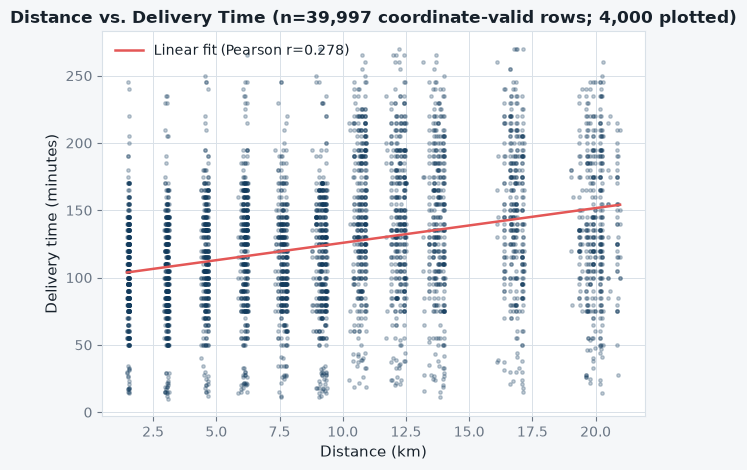

In [9]:
sample = valid_coords.sample(n=min(4000, len(valid_coords)), random_state=42)
z = np.polyfit(valid_coords["distance_km"], valid_coords["Delivery_Time"], 1)
xs = np.linspace(valid_coords["distance_km"].min(), valid_coords["distance_km"].max(), 100)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sample["distance_km"], sample["Delivery_Time"], s=6, alpha=0.25, color=NAVY)
ax.plot(xs, np.polyval(z, xs), color=CORAL, linewidth=1.8,
        label=f"Linear fit (Pearson r={t4['correlation_coefficient']:.3f})")
ax.set_title(f"Distance vs. Delivery Time (n={len(valid_coords):,} coordinate-valid rows; {len(sample):,} plotted)")
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Delivery time (minutes)")
ax.legend()
plt.show()


**Key observation:** Pearson r=0.2781 (r²=0.0774) — **weak**, and notably
**smaller than traffic's effect size (ε²=0.1404) and comparable to
weather's (ε²=0.0517)** — this comparison, per the documented framing, is
the answer to "is delivery time condition-driven or distance-driven":
condition-driven (traffic especially) in relative terms, not distance being
unimportant in isolation.

**Limitation:** Correlational, not causal. Restricted to the 91.6% of rows
with valid coordinates.


## Supporting: Delivery Time by Agent Age Band

Not one of the 5 formally-tested hypotheses, but part of the approved
correlation analysis (`03_correlation_and_pareto.py`'s
`agent_age_correlations`) — included here as a supporting visual for the
agent-attribute picture.


agent_age vs delivery_time: 0.2585 (r^2 = 0.0668 )


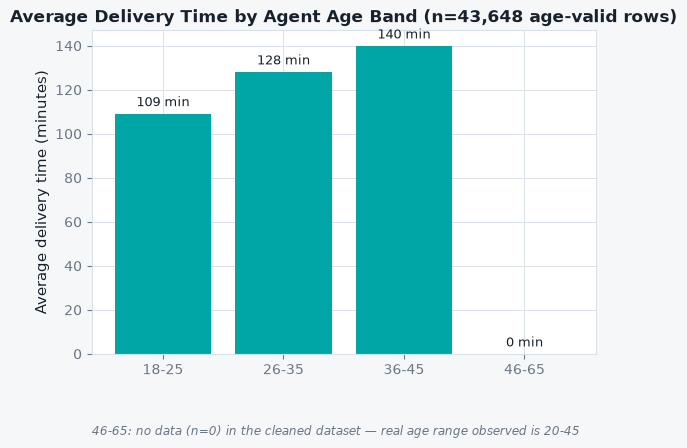

,mean,count
age_band,,
18-25,109.1857,"12,956.0000"
26-35,128.1532,"21,842.0000"
36-45,139.9475,"8,850.0000"
46-65,NaN,NaN


In [10]:
m3 = importlib.import_module("03_correlation_and_pareto")
age_corr = m3.agent_age_correlations(df)
print("agent_age vs delivery_time:", age_corr["age_vs_delivery_time"]["pearson_r"],
      "(r^2 =", age_corr["age_vs_delivery_time"]["pearson_r_squared"], ")")

valid_age = df.loc[df["agent_age_valid_flag"]].copy()
bins, labels = [17, 25, 35, 45, 65], ["18-25", "26-35", "36-45", "46-65"]
valid_age["age_band"] = pd.cut(valid_age["Agent_Age"], bins=bins, labels=labels)
age_band_means = valid_age.groupby("age_band", observed=True)["Delivery_Time"].agg(["mean", "count"])
age_band_means = age_band_means.reindex(labels)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
bars = ax.bar(age_band_means.index, age_band_means["mean"].fillna(0), color=TEAL)
annotate_bars(ax, bars, fmt="{:.0f} min", offset=2)
ax.set_title(f"Average Delivery Time by Agent Age Band (n={len(valid_age):,} age-valid rows)")
ax.set_ylabel("Average delivery time (minutes)")
sample_size_caption(ax, "46-65: no data (n=0) in the cleaned dataset — real age range observed is 20-45")
plt.show()
age_band_means


**Key observation:** Delivery time rises with age band across the 3 bands
that have data (18-25: 109.19 min → 36-45: 139.95 min); r=0.2585
(r²=0.0668) — **weak**, same magnitude as the other attribute-level
correlations.

**Limitation:** No agents aged 46-65 are present in the cleaned dataset —
this band cannot be compared. Attribute-level only, same `Agent_ID`
limitation as Test 3.


## Test 5 — Weekend vs. Weekday Delivery Time

**H0:** Mean delivery time is equal between Weekday and Weekend. **H1:**
It differs.


In [11]:
weekday = df.loc[~df["is_weekend"], "Delivery_Time"].to_numpy()
weekend = df.loc[df["is_weekend"], "Delivery_Time"].to_numpy()
results["test_5_weekend_vs_weekday"] = m4._run_two_group_test(
    "Weekend vs. weekday delivery time", weekday, "Weekday", weekend, "Weekend", rng,
)
t5 = results["test_5_weekend_vs_weekday"]
print(f"Test selected: {t5['test_selected']}")
print(f"p-value: {t5['p_value']:.4f}   Significant: {t5['significant_at_alpha_0.05']}   "
      f"Cohen's d: {t5['effect_size_value']} -> {t5['effect_size_band'].upper()}")


Test selected: Mann-Whitney U test
p-value: 0.9658   Significant: False   Cohen's d: -0.0013 -> NEGLIGIBLE


**Key observation:** p=0.9658 — **not statistically significant**, and the
effect size is negligible (d=-0.0013) regardless. This is the one test in
this notebook where the null hypothesis is not rejected: weekend/weekday is
not a meaningful delay factor in this dataset. Reported as a clean null
result, not a "failed" test.

**Limitation:** None beyond the general ~8-week dataset window.


## Summary Table


In [12]:
summary_rows = []
for key, label, stat_key in [
    ("test_1_traffic_vs_delivery_time", "1 — Traffic (4 groups)", "test_statistic"),
    ("test_2_weather_vs_delivery_time", "2 — Weather (6 groups)", "test_statistic"),
    ("test_2b_clear_vs_adverse_weather", "2b — Clear vs. Adverse weather", "test_statistic"),
    ("test_3_agent_rating_vs_delivery_time", "3 — Agent rating vs. time", "correlation_coefficient"),
    ("test_4_distance_vs_delivery_time", "4 — Distance vs. time", "correlation_coefficient"),
    ("test_5_weekend_vs_weekday", "5 — Weekend vs. weekday", "test_statistic"),
]:
    r = results[key]
    summary_rows.append({
        "Test": label,
        "Test used": r["test_selected"],
        "Statistic": r[stat_key],
        "p-value": r["p_value"],
        "Effect size": r["effect_size_value"] if "effect_size_value" in r else r["correlation_coefficient"],
        "Band": r["effect_size_band"],
        "Significant (a=0.05)": r["significant_at_alpha_0.05"],
    })
summary_df = pd.DataFrame(summary_rows)
summary_df


,Test,Test used,Statistic,p-value,Effect size,Band,Significant (a=0.05)
0,1 — Traffic (4 groups),Kruskal-Wallis H-test,"6,132.4554",0.0000,0.1404,large,True
1,2 — Weather (6 groups),Kruskal-Wallis H-test,"2,262.8928",0.0000,0.0517,small,True
2,2b — Clear vs. Adverse weather,Mann-Whitney U test,"88,955,306.0000",0.0000,-0.4965,small,True
3,3 — Agent rating vs. time,"Spearman correlation (fallback, linearity assu...",-0.2601,0.0000,-0.2601,weak,True
4,4 — Distance vs. time,Pearson correlation (primary),0.2781,0.0000,0.2781,weak,True
5,5 — Weekend vs. weekday,Mann-Whitney U test,"190,043,643.5000",0.9658,-0.0013,negligible,False


## Reconciliation Against the Approved `output/statistical_test_results.json`

This notebook computed every result above independently (same functions,
same fixed RNG seed and call order as the approved
`python/analysis/04_statistical_tests.py`). This cell confirms the fresh
notebook results match the stored, approved JSON exactly — the JSON file
itself is only **read**, never written, by this notebook.


In [13]:
import json
with open(project_root / "output" / "statistical_test_results.json") as f:
    approved = json.load(f)

check_fields = ["p_value", "effect_size_value", "significant_at_alpha_0.05"]
all_match = True
for key in results:
    for field in check_fields:
        fresh_val = results[key].get(field)
        approved_val = approved[key].get(field)
        match = fresh_val == approved_val
        all_match = all_match and match
        status = "OK" if match else "MISMATCH"
        if not match:
            print(f"[{status}] {key}.{field}: notebook={fresh_val!r} vs approved={approved_val!r}")

print("ALL RESULTS MATCH output/statistical_test_results.json EXACTLY" if all_match
      else "DISCREPANCY FOUND -- see above, do not silently reconcile")


ALL RESULTS MATCH output/statistical_test_results.json EXACTLY


---

**Next:** [`06_sql_cross_validation.ipynb`](06_sql_cross_validation.ipynb) —
reconciling these same-layer (Python) KPIs against the independently-built
SQL layer from Phase 3.
